# Scraping Statistics Data

In [10]:
import os
import time
import calendar
import shutil
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from webdriver_manager.chrome import ChromeDriverManager

# --- CONFIGURATION ---
DOWNLOAD_DIR = os.path.join(os.getcwd(), "Airline_Monthly_Stat") # Changed folder name
START_YEAR = 2015
END_YEAR = 2025
TARGET_URL = "https://www.transtats.bts.gov/ontime/Airline.aspx"

# 1. Create Download Directory
if not os.path.exists(DOWNLOAD_DIR):
    os.makedirs(DOWNLOAD_DIR)

# 2. Setup Chrome
chrome_options = webdriver.ChromeOptions()
prefs = {"download.default_directory": DOWNLOAD_DIR}
chrome_options.add_experimental_option("prefs", prefs)
# chrome_options.add_argument("--headless") # Recommended to uncomment this if running for hours

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

try:
    print("Opening Website...")
    driver.get(TARGET_URL)
    time.sleep(5) # Give it extra time to load initially

    # 3. GET ALL AIRLINES FROM DROPDOWN
    try:
        airline_dropdown = Select(driver.find_element(By.ID, "cboAirline"))
        # Create a list of tuples: (Airline_Code, Airline_Name)
        # We ignore options that have an empty value (like "Select Airline")
        airlines_to_scrape = [
            (opt.get_attribute("value"), opt.text) 
            for opt in airline_dropdown.options 
            if opt.get_attribute("value")
        ]
        print(f"Found {len(airlines_to_scrape)} airlines to process.")
    except Exception as e:
        print(f"Could not load airline list: {e}")
        driver.quit()
        exit()

    # --- LOOP AIRLINES ---
    for airline_code, airline_name in airlines_to_scrape:
        print(f"\n=======================================================")
        print(f"Starting: {airline_name} ({airline_code})")
        print(f"=======================================================")

        # Select the current airline
        try:
            Select(driver.find_element(By.ID, "cboAirline")).select_by_value(airline_code)
            time.sleep(2)
        except Exception as e:
            print(f"Could not select {airline_name}. Skipping to next. Error: {e}")
            continue

        # --- LOOP YEARS ---
        for year in range(START_YEAR, END_YEAR + 1):
            
            # --- LOOP MONTHS ---
            for month in range(1, 13):
                # Skip future dates 
                if year == 2026 and month > 2:
                    break

                # Calculate the last day (28, 30, or 31)
                last_day = calendar.monthrange(year, month)[1]
                month_name = calendar.month_name[month]
                
                print(f" -> Processing: {airline_code} - {month_name} {year}...")

                try:
                    # --- STEP 1: SET YEARS FIRST ---
                    Select(driver.find_element(By.ID, "stdateyear")).select_by_value(str(year))
                    Select(driver.find_element(By.ID, "eddateyear")).select_by_value(str(year))
                    
                    # --- STEP 2: SET MONTHS ---
                    Select(driver.find_element(By.ID, "stdatemon")).select_by_value(str(month))
                    Select(driver.find_element(By.ID, "eddatemon")).select_by_value(str(month))
                    
                    time.sleep(1) # Wait for Day dropdown to populate

                    # --- STEP 3: SET DAYS ---
                    Select(driver.find_element(By.ID, "stdateday")).select_by_value("1")
                    Select(driver.find_element(By.ID, "eddateday")).select_by_value(str(last_day))

                    # --- STEP 4: SUBMIT ---
                    driver.find_element(By.ID, "btnSubmit").click()
                    
                    time.sleep(2) # Wait for table to load

                    # --- STEP 5: DOWNLOAD CSV ---
                    try:
                        driver.find_element(By.ID, "DL_CSV").click()
                        time.sleep(2) # Wait for download

                        # --- RENAME FILE ---
                        files = [f for f in os.listdir(DOWNLOAD_DIR) if f.endswith(".csv")]
                        if files:
                            full_paths = [os.path.join(DOWNLOAD_DIR, f) for f in files]
                            newest_file = max(full_paths, key=os.path.getctime)
                            
                            # Target Name: AA_2015_01.csv, UA_2015_01.csv, etc.
                            new_name = os.path.join(DOWNLOAD_DIR, f"{airline_code}_{year}_{month:02d}.csv")
                            
                            if newest_file != new_name:
                                if os.path.exists(new_name):
                                    os.remove(new_name)
                                shutil.move(newest_file, new_name)
                                print(f"    [Saved]: {airline_code}_{year}_{month:02d}.csv")
                    
                    except Exception as dl_error:
                         print(f"    [Skip]: No download link (Data missing for this month).")

                except Exception as e:
                    print(f"    [Error] on {month_name} {year}: {e}")
                    # If the page crashed, we need to make sure the airline is re-selected for the next loop
                    try:
                         driver.get(TARGET_URL)
                         time.sleep(3)
                         Select(driver.find_element(By.ID, "cboAirline")).select_by_value(airline_code)
                    except:
                         pass
                    continue

                time.sleep(1)

finally:
    driver.quit()
    print("\nScraping Complete for all airlines.")

Opening Website...
Found 34 airlines to process.

Starting: ATA Airlines (TZ) (TZ)
 -> Processing: TZ - January 2015...
    [Skip]: No download link (Data missing for this month).
 -> Processing: TZ - February 2015...
    [Skip]: No download link (Data missing for this month).
 -> Processing: TZ - March 2015...
    [Skip]: No download link (Data missing for this month).
 -> Processing: TZ - April 2015...
    [Skip]: No download link (Data missing for this month).
 -> Processing: TZ - May 2015...

Scraping Complete for all airlines.


KeyboardInterrupt: 

# Merging Statistics Data

In [11]:
import pandas as pd
import glob
import os
import re
from datetime import datetime

# --- CONFIGURATION ---
source_folder = "Airline_Monthly_Stat"  # Folder with your downloaded files
output_file = "All_Airlines_Master_Data.csv"

# 1. Find all CSV files in the folder
files = glob.glob(os.path.join(source_folder, "*.csv"))

if not files:
    print(f"No files found in '{source_folder}'. Please check the folder name.")
else:
    print(f"Found {len(files)} files. Starting robust merge...")

    all_monthly_data = []

    for file in files:
        try:
            # --- ROBUST METADATA EXTRACTION ---
            with open(file, 'r', encoding='utf-8') as f:
                lines = [next(f) for _ in range(3)]
                
            airline_line = lines[1].strip()  # Example: "Airline: American Airlines Inc. (AA)"
            time_line = lines[2].strip()     # Example: "Time Period: Thursday, January 1, 2015 to..."

            # 1. Extract BOTH Airline Name and Airline Code
            # This regex captures everything after "Airline: " up to the "(" as the Name, 
            # and everything inside the "()" as the Code.
            match = re.search(r'Airline:\s*(.*?)\s*\((.*?)\)$', airline_line)
            if match:
                airline_name = match.group(1).strip() # "American Airlines Inc."
                airline_code = match.group(2).strip() # "AA"
            else:
                airline_name = "UNKNOWN"
                airline_code = "UNKNOWN"

            # 2. Extract Year and Month from the "Time Period" text
            date_part = time_line.split(" to ")[0].replace("Time Period: ", "").strip()
            parsed_date = datetime.strptime(date_part, "%A, %B %d, %Y")
            year = parsed_date.year
            month = parsed_date.month

            # --- EXTRACT TABLE 1: ALL FLIGHTS ---
            df_all = pd.read_csv(file, skiprows=4, nrows=1)
            df_all.columns = [f"All_{col.strip()}" for col in df_all.columns]

            # --- EXTRACT TABLE 2: LATE FLIGHTS ---
            df_late = pd.read_csv(file, skiprows=8, nrows=1)
            df_late.columns = [f"Late_{col.strip()}" for col in df_late.columns]

            # --- EXTRACT TABLE 3: CAUSE OF DELAY ---
            df_cause = pd.read_csv(file, skiprows=12, nrows=1)
            df_cause.columns = [f"Cause_{col.strip()}" for col in df_cause.columns]

            # --- COMBINE TABLES ---
            combined_row = pd.concat([
                df_all.reset_index(drop=True),
                df_late.reset_index(drop=True),
                df_cause.reset_index(drop=True)
            ], axis=1)

            # --- ADD ACCURATE METADATA (WITH FULL NAME) ---
            combined_row.insert(0, 'Airline_Name', airline_name)
            combined_row.insert(1, 'Airline_Code', airline_code)
            combined_row.insert(2, 'Year', year)
            combined_row.insert(3, 'Month', month)

            # --- CLEANUP ---
            cols_to_drop = [c for c in combined_row.columns if 'Carrier' in c]
            combined_row.drop(columns=cols_to_drop, inplace=True, errors='ignore')

            all_monthly_data.append(combined_row)

        except Exception as e:
            print(f"Error processing {os.path.basename(file)}: {e}")

    # 2. CREATE MASTER DATAFRAME
    if all_monthly_data:
        master_df = pd.concat(all_monthly_data, ignore_index=True)

        # 3. SORT BY AIRLINE NAME, THEN DATE
        master_df.sort_values(by=['Airline_Name', 'Year', 'Month'], inplace=True)

        # 4. SAVE TO CSV
        master_df.to_csv(output_file, index=False)
        print(f"\nSuccess! Merged {len(master_df)} monthly records into '{output_file}'.")
        print(master_df.head()) # Show first few rows
    else:
        print("No valid data rows extracted.")

Found 2135 files. Starting robust merge...

Success! Merged 2135 monthly records into 'All_Airlines_Master_Data.csv'.
             Airline_Name Airline_Code  Year  Month  All_Total Number  \
263  Alaska Airlines Inc.           AS  2015      1             13257   
264  Alaska Airlines Inc.           AS  2015      2             12194   
265  Alaska Airlines Inc.           AS  2015      3             14276   
266  Alaska Airlines Inc.           AS  2015      4             13974   
267  Alaska Airlines Inc.           AS  2015      5             14682   

     All_Average Departure Delay (minutes)  \
263                                   3.17   
264                                   2.70   
265                                   3.06   
266                                   0.00   
267                                  -0.19   

     All_Average Taxi-Out Time (minutes)  \
263                                15.59   
264                                14.82   
265                               

# Merging Employee Data

In [12]:
import pandas as pd
import glob
import os

# --- CONFIGURATION ---
source_folder = "Employee"  # Make sure this matches your folder name
output_file = "All_Airlines_Employee_Merged.csv" # Updated output name

# 1. Define Mappings

# Mapping dictionary for Entity codes
entity_map = {
    'A': 'Atlantic',
    'D': 'Domestic',
    'I': 'International',
    'L': 'Latin America',
    'P': 'Pacific',
    'S': 'System'
}

# Mapping dictionary for Column Headers (Employee Data P-10)
column_header_map = {
    'YEAR': 'Year',
    'CARRIER_NAME': 'Carrier Name',
    'ENTITY': "Carrier's Operation Region",
    'GENERAL_MANAGE': 'General Managers',
    'PILOTS_COPILOTS': 'Pilots and Copilots',
    'OTHER_FLT_PERS': 'Other Flight Personnel',
    'PASS_GEN_SVC_ADMIN': 'Passenger/General Services & Administration',
    'MAINTENANCE': 'Maintenance Employees',
    'ARCFT_TRAF_HANDLING_GRP1': 'Aircraft Traffic Handling Group 1 Employees',
    'GEN_ARCFT_TRAF_HANDLING': 'General Aircraft Traffic Handling Employees',
    'AIRCRAFT_CONTROL': 'Aircraft Control Employees',
    'PASSENGER_HANDLING': 'Passenger Handling Employees',
    'CARGO_HANDLING': 'Cargo Handling Employees',
    'TRAINEES_INTRUCTOR': 'Trainees and Instructor',
    'STATISTICAL': 'Statistical Employees',
    'TRAFFIC_SOLICITERS': 'Traffic Soliciters',
    'OTHER': 'Other Employees',
    'TRANSPORT_RELATED': 'Transport Related Employees',
    'TOTAL': 'Total Employees'
}

# 2. Find all CSV files in the folder
files = glob.glob(os.path.join(source_folder, "*.csv"))

if not files:
    print(f"No CSV files found in '{source_folder}'. Please check the folder path.")
else:
    print(f"Found {len(files)} files. Starting merge...")

    all_data = []

    for file in files:
        try:
            # Read the CSV file
            df = pd.read_csv(file)
            
            # Append all rows directly (No Delta filter)
            if not df.empty:
                all_data.append(df)
                print(f" -> Processed: {os.path.basename(file)} ({len(df)} rows)")

        except Exception as e:
            print(f"Error reading {file}: {e}")

    # 3. Concatenate all data
    if all_data:
        merged_df = pd.concat(all_data, ignore_index=True)

        # 4. Map the 'ENTITY' column to full descriptions
        if 'ENTITY' in merged_df.columns:
            # Replace the codes with descriptions using the map
            merged_df['ENTITY'] = merged_df['ENTITY'].map(entity_map).fillna(merged_df['ENTITY'])
            print(" -> Entity column updated.")
        
        # 5. Apply Column Header Mapping (THIS WAS MISSING!)
        merged_df.rename(columns=column_header_map, inplace=True)
        print(" -> Column headers renamed to match BTS descriptions.")
        
        # 6. Save the final merged file
        merged_df.to_csv(output_file, index=False)
        print(f"\nSuccess! Saved merged data to: {output_file}")
        print(merged_df.head()) # Show first few rows
        
    else:
        print("No data found in the files.")

Found 11 files. Starting merge...
 -> Processed: T_F41SCHEDULE_P10_1.csv (92 rows)
 -> Processed: T_F41SCHEDULE_P10_10.csv (97 rows)
 -> Processed: T_F41SCHEDULE_P10_11.csv (97 rows)
 -> Processed: T_F41SCHEDULE_P10_2.csv (96 rows)
 -> Processed: T_F41SCHEDULE_P10_3.csv (104 rows)
 -> Processed: T_F41SCHEDULE_P10_4.csv (94 rows)
 -> Processed: T_F41SCHEDULE_P10_5.csv (93 rows)
 -> Processed: T_F41SCHEDULE_P10_6.csv (94 rows)
 -> Processed: T_F41SCHEDULE_P10_7.csv (93 rows)
 -> Processed: T_F41SCHEDULE_P10_8.csv (91 rows)
 -> Processed: T_F41SCHEDULE_P10_9.csv (96 rows)
 -> Entity column updated.
 -> Column headers renamed to match BTS descriptions.

Success! Saved merged data to: All_Airlines_Employee_Merged.csv
   Year                 Carrier Name Carrier's Operation Region  \
0  2014                  ABX Air Inc                   Domestic   
1  2014  Air Transport International                   Domestic   
2  2014  Air Transport International              International   
3  2014  A

# Merging Financial Data

In [13]:
import pandas as pd
import glob
import os

# --- CONFIGURATION ---
source_folder = "Financial"  # Folder containing your downloaded financial CSVs
output_file = "Airline_Financial_Data_Merged.csv"

# 1. Define Mappings

# Map for Region/Entity codes
# Based on BTS standard region codes
entity_value_map = {
    'A': 'Atlantic',
    'D': 'Domestic',
    'I': 'International',
    'L': 'Latin America',
    'P': 'Pacific',
    'S': 'System'
}

# Map for Column Headers (Variables -> Descriptions)
# Derived from BTS Schedule P-6 Descriptions
column_header_map = {
    'SALARIES_MGT': 'General Management Personnel',
    'SALARIES_FLIGHT': 'Flight Personnel',
    'SALARIES_MAINT': 'Maintenance Labor',
    'SALARIES_TRAFFIC': 'Aircraft and Traffic Handling Personnel',
    'SALARIES_OTHER': 'Other Personnel',
    'SALARIES': 'Total Salaries',
    'BENEFITS_PERSONNEL': 'Personnel Expense',
    'BENEFITS_PENSIONS': 'Employee Benefits and Pensions',
    'BENEFITS_PAYROLL': 'Payroll Taxes',
    'BENEFITS': 'Total Related Fringe Benefits',
    'SALARIES_BENEFITS': 'Total Salaries and Related Fringe Benefits',
    'AIRCRAFT_FUEL': 'Aircraft Fuel and Oil',
    'MAINT_MATERIAL': 'Maintenance Material',
    'FOOD': 'Passenger Food',
    'OTHER_MATERIALS': 'Other Materials',
    'MATERIALS_TOTAL': 'Total Materials',
    'ADVERTISING': 'Advertising and Other Promotions',
    'COMMUNICATION': 'Communication',
    'INSURANCE': 'Insurance',
    'OUTSIDE_EQUIP': 'Outside Flight Equipment Maintenance',
    'COMMISIONS_PAX': 'Traffic Commissions - Passenger',
    'COMMISSIONS_CARGO': 'Traffic Commissions - Cargo',
    'OTHER_SERVICES': 'Other Services',
    'SERVICES_TOTAL': 'Total Services',
    'LANDING_FEES': 'Landing Fees',
    'RENTALS': 'Rentals',
    'DEPRECIATION': 'Depreciation',
    'AMORTIZATION': 'Amortization',
    'OTHER': 'Other Expenses',
    'TRANS_EXPENSE': 'Transport Related Expense',
    'OP_EXPENSE': 'Total Operating Expenses',
    'CARRIER_NAME': 'Carrier Name',
    'REGION': "Carrier's Operation Region",
    'YEAR': 'Year',
    'QUARTER': 'Quarter'
}

# 2. Find all CSV files
files = glob.glob(os.path.join(source_folder, "*.csv"))

if not files:
    print(f"No CSV files found in '{source_folder}'. Please check the folder path.")
else:
    print(f"Found {len(files)} files. Starting merge...")

    all_data = []

    # 3. Read and append all files (Added this loop back in)
    for file in files:
        try:
            # Read the CSV file
            df = pd.read_csv(file)
            
            # Append all rows directly (No Delta filter)
            if not df.empty:
                all_data.append(df)
                print(f" -> Processed: {os.path.basename(file)} ({len(df)} rows)")

        except Exception as e:
            print(f"Error reading {file}: {e}")

    # 4. Concatenate and Clean
    if all_data:
        merged_df = pd.concat(all_data, ignore_index=True)

        # 5. Apply Region Code Mapping (Changing the values inside the column)
        # Note: In P-6 data, the column is often named 'REGION'
        if 'REGION' in merged_df.columns:
            merged_df['REGION'] = merged_df['REGION'].map(entity_value_map).fillna(merged_df['REGION'])
            print(" -> Region codes updated to descriptions.")

        # 6. Apply Column Header Mapping
        merged_df.rename(columns=column_header_map, inplace=True)
        print(" -> Column headers renamed to match BTS descriptions.")
        
        # 7. Sort by Year and Quarter if available
        sort_cols = [c for c in ['Year', 'Quarter'] if c in merged_df.columns]
        if sort_cols:
            merged_df.sort_values(by=sort_cols, inplace=True)
        
        # 8. Save to CSV
        merged_df.to_csv(output_file, index=False)
        print(f"\nSuccess! Saved merged data to: {output_file}")
        print(merged_df.head()) 
        
    else:
        print("No data found in the files.")

Found 12 files. Starting merge...
 -> Processed: T_F41SCHEDULE_P6_1.csv (403 rows)
 -> Processed: T_F41SCHEDULE_P6_10.csv (404 rows)
 -> Processed: T_F41SCHEDULE_P6_11.csv (384 rows)
 -> Processed: T_F41SCHEDULE_P6_12.csv (283 rows)
 -> Processed: T_F41SCHEDULE_P6_2.csv (414 rows)
 -> Processed: T_F41SCHEDULE_P6_3.csv (407 rows)
 -> Processed: T_F41SCHEDULE_P6_4.csv (404 rows)
 -> Processed: T_F41SCHEDULE_P6_5.csv (393 rows)
 -> Processed: T_F41SCHEDULE_P6_6.csv (398 rows)
 -> Processed: T_F41SCHEDULE_P6_7.csv (400 rows)
 -> Processed: T_F41SCHEDULE_P6_8.csv (397 rows)
 -> Processed: T_F41SCHEDULE_P6_9.csv (389 rows)
 -> Region codes updated to descriptions.
 -> Column headers renamed to match BTS descriptions.

Success! Saved merged data to: Airline_Financial_Data_Merged.csv
    General Management Personnel  Flight Personnel  Maintenance Labor  \
2                            0.0              0.00               0.00   
4                            0.0            111.45              79.

# Data Cleaning

 INITIATING STRICT DATA CLEANING & VISUALIZATION

[1] Cleaning Flight Statistics Data...


C:\Users\Pongw\AppData\Local\Temp\ipykernel_47100\715323547.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Raw Data", "Cleaned Data"], y=[flight_rows_before, flight_rows_after], palette=["#FF9999", "#66B2FF"])


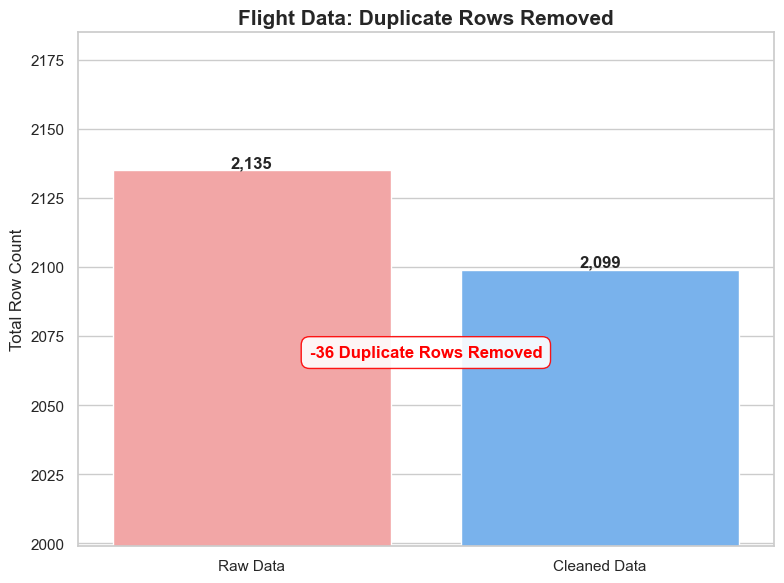

    ✓ Dropped 36 duplicates. Saved 'Cleaned_Flight_Data.csv' and 'Fig1_Flight_Cleaning.png'

[2] Cleaning Financial Data...


C:\Users\Pongw\AppData\Local\Temp\ipykernel_47100\715323547.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Raw Data", "Cleaned Data"], y=[missing_before, missing_after], palette=["#FFA07A", "#32CD32"])


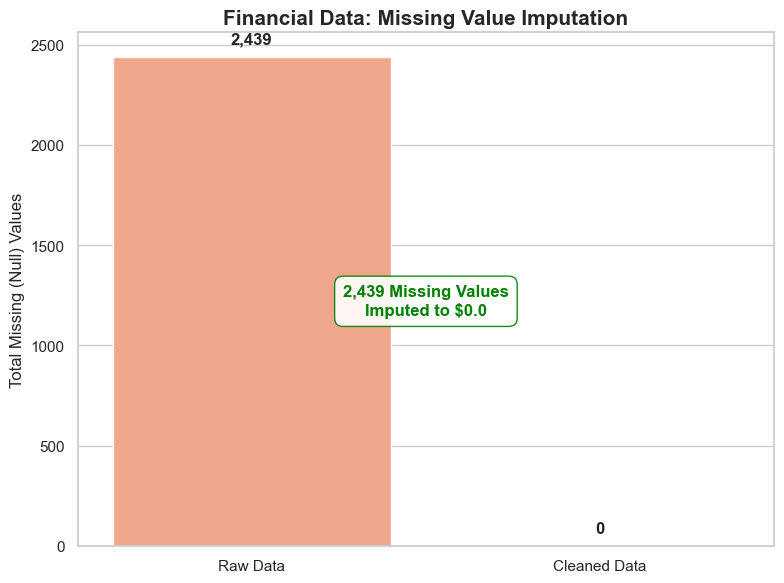

    ✓ Imputed 2439 missing values. Saved 'Cleaned_Financial_Data.csv' and 'Fig2_Financial_Cleaning.png'

[3] Cleaning Employee Data...


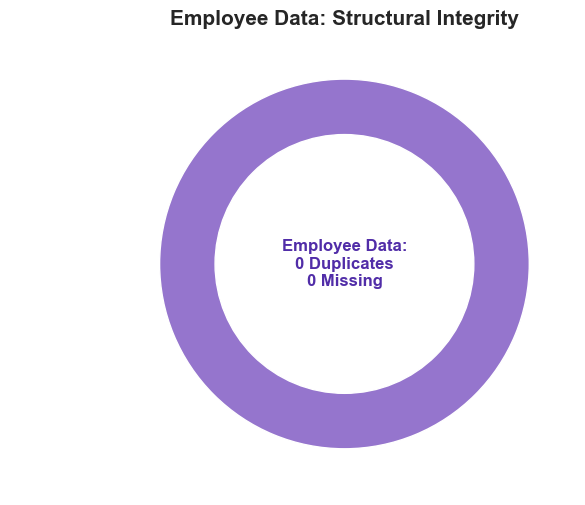

    ✓ Standardized formats. Saved 'Cleaned_Employee_Data.csv' and 'Fig3_Employee_Cleaning.png'

 DATA CLEANING & VISUALIZATION COMPLETE.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
sns.set_theme(style="whitegrid", palette="muted")

def pure_cleaning_with_visuals():
    print("==================================================")
    print(" INITIATING STRICT DATA CLEANING & VISUALIZATION")
    print("==================================================\n")

    # ---------------------------------------------------------
    # 1. CLEANING FLIGHT STATISTICS (DEDUPLICATION)
    # ---------------------------------------------------------
    print("[1] Cleaning Flight Statistics Data...")
    try:
        df_flight = pd.read_csv("All_Airlines_Master_Data.csv")
        
        # Track before
        flight_rows_before = len(df_flight)
        
        # Action: Deduplication & Standardization
        df_flight = df_flight.drop_duplicates()
        for col in ["Airline_Name", "Airline_Code"]:
            if col in df_flight.columns:
                df_flight[col] = df_flight[col].astype(str).str.strip()
        
        # Track after
        flight_rows_after = len(df_flight)
        dupes_removed = flight_rows_before - flight_rows_after
        
        # Visualization 1
        plt.figure(figsize=(8, 6))
        sns.barplot(x=["Raw Data", "Cleaned Data"], y=[flight_rows_before, flight_rows_after], palette=["#FF9999", "#66B2FF"])
        plt.title("Flight Data: Duplicate Rows Removed", fontsize=15, fontweight='bold')
        plt.ylabel("Total Row Count", fontsize=12)
        plt.ylim(max(0, flight_rows_after - 100), flight_rows_before + 50)
        
        plt.text(0, flight_rows_before, f'{flight_rows_before:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        plt.text(1, flight_rows_after, f'{flight_rows_after:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        if dupes_removed > 0:
            plt.text(0.5, flight_rows_after - 30, f"-{dupes_removed} Duplicate Rows Removed", 
                     ha='center', va='center', color='red', fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.5'))
            
        plt.tight_layout()
        plt.savefig("Fig1_Flight_Cleaning.png", dpi=300)
        plt.show()

        # Save Cleaned Data
        df_flight.to_csv("Cleaned_Flight_Data.csv", index=False)
        print(f"    ✓ Dropped {dupes_removed} duplicates. Saved 'Cleaned_Flight_Data.csv' and 'Fig1_Flight_Cleaning.png'")
    except Exception as e:
        print(f"    [X] Error: {e}")


    # ---------------------------------------------------------
    # 2. CLEANING FINANCIAL DATA (IMPUTATION & DOMAIN FIX)
    # ---------------------------------------------------------
    print("\n[2] Cleaning Financial Data...")
    try:
        df_fin = pd.read_csv("Airline_Financial_Data_Merged.csv", low_memory=False)
        
        # Track before
        missing_before = df_fin.isnull().sum().sum()
        
        # Action: Domain Fix & Missing Value Imputation
        if 'UNIQUE_CARRIER_ENTITY' in df_fin.columns:
            df_fin['UNIQUE_CARRIER_ENTITY'] = df_fin['UNIQUE_CARRIER_ENTITY'].astype(str).str.strip()
            
        num_cols = df_fin.select_dtypes(include=['float64', 'int64']).columns
        df_fin[num_cols] = df_fin[num_cols].fillna(0.0)
        
        if 'Carrier Name' in df_fin.columns:
            df_fin['Carrier Name'] = df_fin['Carrier Name'].astype(str).str.strip()
            
        # Track after
        missing_after = df_fin.isnull().sum().sum()
        
        # Visualization 2
        plt.figure(figsize=(8, 6))
        sns.barplot(x=["Raw Data", "Cleaned Data"], y=[missing_before, missing_after], palette=["#FFA07A", "#32CD32"])
        plt.title("Financial Data: Missing Value Imputation", fontsize=15, fontweight='bold')
        plt.ylabel("Total Missing (Null) Values", fontsize=12)
        
        plt.text(0, missing_before + 50, f'{missing_before:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        plt.text(1, missing_after + 50, f'{missing_after:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        
        if missing_before > 0:
            plt.text(0.5, missing_before * 0.5, f"{missing_before:,} Missing Values\nImputed to $0.0", 
                     ha='center', va='center', color='green', fontweight='bold',
                     bbox=dict(facecolor='white', alpha=0.9, edgecolor='green', boxstyle='round,pad=0.5'))
            
        plt.tight_layout()
        plt.savefig("Fig2_Financial_Cleaning.png", dpi=300)
        plt.show()

        # Save Cleaned Data
        df_fin.to_csv("Cleaned_Financial_Data.csv", index=False)
        print(f"    ✓ Imputed {missing_before} missing values. Saved 'Cleaned_Financial_Data.csv' and 'Fig2_Financial_Cleaning.png'")
    except Exception as e:
        print(f"    [X] Error: {e}")


    # ---------------------------------------------------------
    # 3. CLEANING EMPLOYEE DATA (STANDARDIZATION)
    # ---------------------------------------------------------
    print("\n[3] Cleaning Employee Data...")
    try:
        df_emp = pd.read_csv("All_Airlines_Employee_Merged.csv")
        
        # Action: Standardize Strings & Enforce Integers
        for col in ["Carrier Name", "Carrier's Operation Region"]:
            if col in df_emp.columns:
                df_emp[col] = df_emp[col].astype(str).str.strip()
                
        num_cols_emp = df_emp.select_dtypes(include=['float64']).columns
        for col in num_cols_emp:
            df_emp[col] = df_emp[col].fillna(0).astype(int)
            
        # Visualization 3: Data Quality Verification (Donut Chart)
        # Since this dataset had 0 missing values and 0 duplicates, we visualize the successful verification
        plt.figure(figsize=(6, 6))
        plt.pie([1], labels=["100% Cleaned\n& Verified"], colors=["#9575CD"], 
                textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'})
        
        centre_circle = plt.Circle((0,0), 0.70, fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)
        
        plt.text(0, 0, "Employee Data:\n0 Duplicates\n0 Missing", ha='center', va='center', 
                 fontsize=12, fontweight='bold', color='#512DA8')
        plt.title("Employee Data: Structural Integrity", fontsize=15, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig("Fig3_Employee_Cleaning.png", dpi=300)
        plt.show()

        # Save Cleaned Data
        df_emp.to_csv("Cleaned_Employee_Data.csv", index=False)
        print("    ✓ Standardized formats. Saved 'Cleaned_Employee_Data.csv' and 'Fig3_Employee_Cleaning.png'")
    except Exception as e:
        print(f"    [X] Error: {e}")

    print("\n==================================================")
    print(" DATA CLEANING & VISUALIZATION COMPLETE.")
    print("==================================================")

if __name__ == "__main__":
    pure_cleaning_with_visuals()

# Data Transformantion

In [15]:
import pandas as pd

def monthly_master_integration():
    print("==================================================")
    print(" EXECUTING 3-INTO-1 MERGE (MONTHLY CADENCE)")
    print("==================================================\n")

    try:
        # 1. LOAD THE 3 CLEANED FILES
        print("[1] Loading Cleaned Datasets...")
        df_flight = pd.read_csv("Cleaned_Flight_Data.csv")
        df_fin = pd.read_csv("Cleaned_Financial_Data.csv", low_memory=False)
        df_emp = pd.read_csv("Cleaned_Employee_Data.csv")

        # Standardize the joining key for Flight Data
        if 'Airline_Name' in df_flight.columns:
            df_flight = df_flight.rename(columns={'Airline_Name': 'Carrier Name'})

        # Drop incomplete 2025 records so they don't skew the data
        df_flight = df_flight[df_flight['Year'] < 2025]
        df_fin = df_fin[df_fin['Year'] < 2025]

        # ---------------------------------------------------------
        # 2. STRETCH FINANCIALS (Quarterly -> Monthly)
        # ---------------------------------------------------------
        print("[2] Stretching Financials into Monthly estimates...")
        quarter_to_month = {1: [1, 2, 3], 2: [4, 5, 6], 3: [7, 8, 9], 4: [10, 11, 12]}
        fin_monthly = []
        
        # Find all numeric financial columns to divide by 3
        num_cols_fin = [c for c in df_fin.select_dtypes(include=['float64', 'int64']).columns if c not in ['Year', 'Quarter']]
        
        for _, row in df_fin.iterrows():
            months = quarter_to_month.get(row['Quarter'], [])
            for m in months:
                new_row = row.copy()
                new_row['Month'] = m # Assign the specific month (e.g., 1, 2, or 3 for Q1)
                
                # Divide the financial expenses evenly across the 3 months
                for col in num_cols_fin:
                    new_row[col] = row[col] / 3.0
                fin_monthly.append(new_row)
                
        df_fin_monthly = pd.DataFrame(fin_monthly)
        # Drop the now-obsolete Quarter column
        if 'Quarter' in df_fin_monthly.columns:
            df_fin_monthly = df_fin_monthly.drop(columns=['Quarter'])

        # ---------------------------------------------------------
        # 3. STRETCH EMPLOYEES (Yearly -> Monthly)
        # ---------------------------------------------------------
        print("[3] Consolidating and Stretching Employees into Monthly rows...")
        # A. Consolidate the regional splits into Yearly totals
        num_cols_emp = [c for c in df_emp.select_dtypes(include=['int64', 'float64']).columns if c != 'Year']
        emp_yearly = df_emp.groupby(['Carrier Name', 'Year'])[num_cols_emp].sum().reset_index()
        
        # B. Stretch into 12 Monthly rows (Copying the headcount, NOT dividing)
        emp_monthly = []
        for _, row in emp_yearly.iterrows():
            for m in range(1, 13):
                new_row = row.copy()
                new_row['Month'] = m
                emp_monthly.append(new_row)
                
        df_emp_monthly = pd.DataFrame(emp_monthly)

        # ---------------------------------------------------------
        # 4. THE 3-INTO-1 MONTHLY MERGE
        # ---------------------------------------------------------
        print("[4] Executing the Master Inner Joins...")
        
        # Step A: Merge Flight and Monthly Financials
        master_step_1 = pd.merge(df_flight, df_fin_monthly, on=['Carrier Name', 'Year', 'Month'], how='inner')
        
        # Step B: Merge with Monthly Employees
        final_monthly_master = pd.merge(master_step_1, df_emp_monthly, on=['Carrier Name', 'Year', 'Month'], how='inner')

        # ---------------------------------------------------------
        # 5. SAVE THE SINGLE MASTER FILE
        # ---------------------------------------------------------
        final_monthly_master.to_csv("Final_Monthly_Master_Dataset.csv", index=False)
        
        print("\n==================================================")
        print(" ✓ MONTHLY INTEGRATION SUCCESSFUL!")
        print(f" -> Saved As: 'Final_Monthly_Master_Dataset.csv'")
        print(f" -> Final Shape: {final_monthly_master.shape[0]} Rows, {final_monthly_master.shape[1]} Columns")
        print("==================================================")
        
        # Preview the final file to prove they are merged
        print("\nPreview of the single merged file (Notice how they all share Month 1):")
        preview_cols = ['Carrier Name', 'Year', 'Month', 'All_Total Number', 'Total Operating Expenses', 'Total Employees']
        print(final_monthly_master[preview_cols].head(3))

    except Exception as e:
        print(f"Error during Monthly Integration: {e}")

if __name__ == "__main__":
    monthly_master_integration()

 EXECUTING 3-INTO-1 MERGE (MONTHLY CADENCE)

[1] Loading Cleaned Datasets...
[2] Stretching Financials into Monthly estimates...
[3] Consolidating and Stretching Employees into Monthly rows...
[4] Executing the Master Inner Joins...

 ✓ MONTHLY INTEGRATION SUCCESSFUL!
 -> Saved As: 'Final_Monthly_Master_Dataset.csv'
 -> Final Shape: 2956 Rows, 82 Columns

Preview of the single merged file (Notice how they all share Month 1):
           Carrier Name  Year  Month  All_Total Number  \
0  Alaska Airlines Inc.  2015      1             13257   
1  Alaska Airlines Inc.  2015      1             13257   
2  Alaska Airlines Inc.  2015      2             12194   

   Total Operating Expenses  Total Employees  
0              21949.666667            11614  
1             321243.666667            11614  
2              21949.666667            11614  


C:\Users\Pongw\AppData\Local\Temp\ipykernel_47100\4035273098.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=rows, ax=axes[0], palette=["#FF9999", "#66B2FF", "#99FF99", "#9575CD"])
C:\Users\Pongw\AppData\Local\Temp\ipykernel_47100\4035273098.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=cols, ax=axes[1], palette=["#FF9999", "#66B2FF", "#99FF99", "#9575CD"])


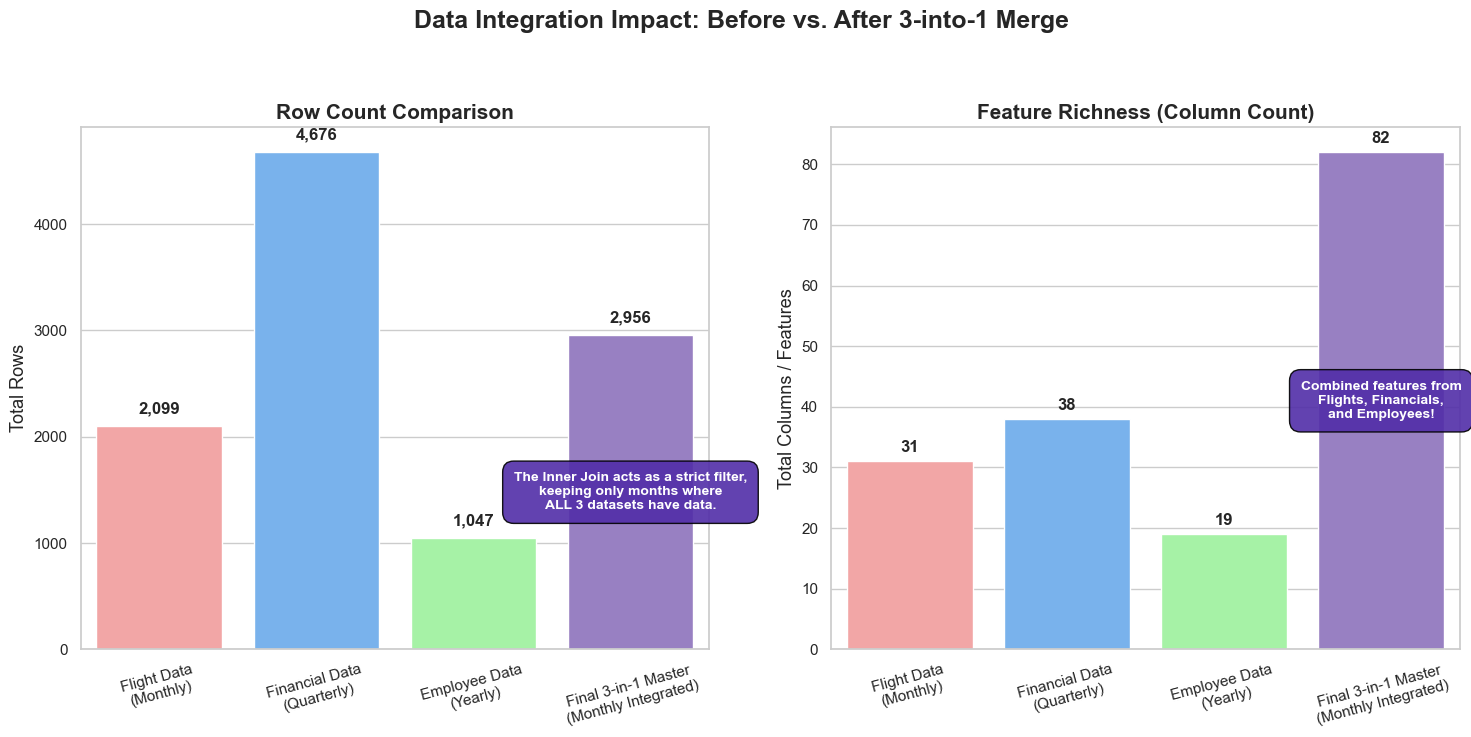

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# 1. Load Cleaned Data 
df_flight = pd.read_csv("Cleaned_Flight_Data.csv")
df_fin = pd.read_csv("Cleaned_Financial_Data.csv", low_memory=False)
df_emp = pd.read_csv("Cleaned_Employee_Data.csv")

# 2. Load the Final Integrated Master File
df_master = pd.read_csv("Final_Monthly_Master_Dataset.csv")

# 3. Prepare Data for Visualization
names = ["Flight Data\n(Monthly)", "Financial Data\n(Quarterly)", "Employee Data\n(Yearly)", "Final 3-in-1 Master\n(Monthly Integrated)"]
rows = [len(df_flight), len(df_fin), len(df_emp), len(df_master)]
cols = [len(df_flight.columns), len(df_fin.columns), len(df_emp.columns), len(df_master.columns)]

# 4. Generate the Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Data Integration Impact: Before vs. After 3-into-1 Merge", fontsize=18, fontweight='bold', y=1.05)

# Subplot A: Row Count
sns.barplot(x=names, y=rows, ax=axes[0], palette=["#FF9999", "#66B2FF", "#99FF99", "#9575CD"])
axes[0].set_title("Row Count Comparison", fontsize=15, fontweight='bold')
axes[0].set_ylabel("Total Rows", fontsize=13)
axes[0].tick_params(axis='x', rotation=15, labelsize=11)

for i, v in enumerate(rows):
    axes[0].text(i, v + (max(rows)*0.02), f"{v:,}", ha='center', va='bottom', fontweight='bold', fontsize=12)

# Subplot B: Column Count
sns.barplot(x=names, y=cols, ax=axes[1], palette=["#FF9999", "#66B2FF", "#99FF99", "#9575CD"])
axes[1].set_title("Feature Richness (Column Count)", fontsize=15, fontweight='bold')
axes[1].set_ylabel("Total Columns / Features", fontsize=13)
axes[1].tick_params(axis='x', rotation=15, labelsize=11)

for i, v in enumerate(cols):
    axes[1].text(i, v + 1, f"{v}", ha='center', va='bottom', fontweight='bold', fontsize=12)

# Add explanatory annotations
axes[0].text(3, rows[3]*0.5, "The Inner Join acts as a strict filter,\nkeeping only months where\nALL 3 datasets have data.", 
             ha='center', va='center', color='white', fontweight='bold', fontsize=10,
             bbox=dict(facecolor='#512DA8', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.8'))

axes[1].text(3, cols[3]*0.5, "Combined features from\nFlights, Financials,\nand Employees!", 
             ha='center', va='center', color='white', fontweight='bold', fontsize=10,
             bbox=dict(facecolor='#512DA8', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.8'))

plt.tight_layout()
plt.savefig("Integration_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()